# 02 — DEM

The NASA HMA 8 m DEM, the only terrain source in the system. No fallback if this
is missing — stage-volume, routing, and 3D terrain all depend on it.

In [1]:
import sys
sys.path.insert(0, "..")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from analysis.hydro.dem import dem_tiles, read_window, elevation_at, window_index

tiles = dem_tiles()
for t in tiles:
    print(t.name)

HMA_DEM8m_MOS_20170716_tile-642.tif
HMA_DEM8m_MOS_20170716_tile-675.tif


In [2]:
import rasterio
for t in tiles:
    with rasterio.open(t) as ds:
        print(f"{t.name}: {ds.width}x{ds.height} @ {ds.res} m, crs={ds.crs.to_epsg() or 'custom Albers'}")
        print(f"  nodata={ds.nodata}, dtype={ds.dtypes[0]}")

HMA_DEM8m_MOS_20170716_tile-642.tif: 12500x12500 @ (8.0, 8.0) m, crs=custom Albers
  nodata=-9999.0, dtype=float32
HMA_DEM8m_MOS_20170716_tile-675.tif: 12500x12500 @ (8.0, 8.0) m, crs=custom Albers
  nodata=-9999.0, dtype=float32


## Vintage — the caveat that matters most

In [3]:
print("DEM acquisition date: 2017-07-16")
print("Event date: 2026-08-26")
print("Gap: 9 years, 1 month")
print()
print("Every routing output in this system carries this caveat: the channel has been")
print("reshaped by an enormous volume of debris since this DEM was captured.")

DEM acquisition date: 2017-07-16
Event date: 2026-08-26
Gap: 9 years, 1 month

Every routing output in this system carries this caveat: the channel has been
reshaped by an enormous volume of debris since this DEM was captured.


## The blockage site

elevation at blockage site: 1745.4 m
window: (750, 750), valid 73.1%


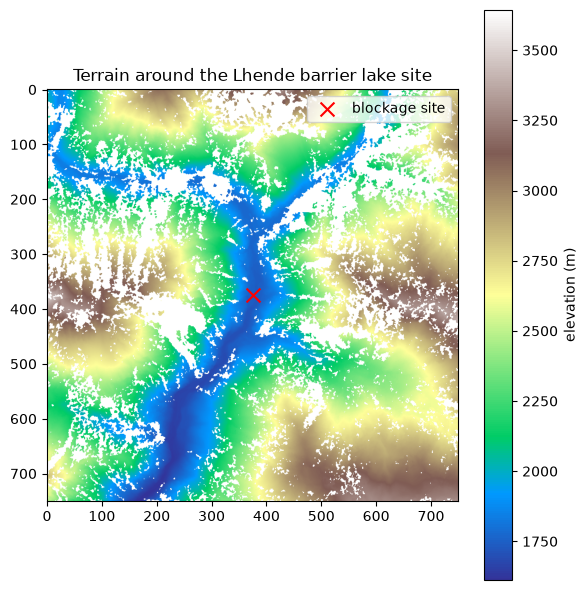

In [4]:
lon, lat = 85.377, 28.271
window = read_window(lon, lat, radius_m=3000)
print(f"elevation at blockage site: {elevation_at(lon, lat):.1f} m")
print(f"window: {window.elevation.shape}, valid {np.isfinite(window.elevation).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(window.elevation, cmap="terrain")
r, c = window_index(window, lon, lat)
ax.scatter([c], [r], c="red", marker="x", s=100, label="blockage site")
ax.set_title("Terrain around the Lhende barrier lake site")
plt.colorbar(im, ax=ax, label="elevation (m)")
ax.legend()
plt.tight_layout()
plt.savefig("../dist/dem_window.png", dpi=100)
plt.show()

## Stage-volume curve at the barrier site

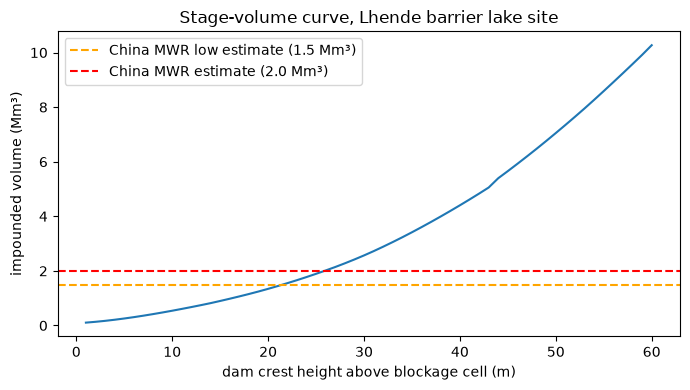

volume at +21m: 1.44 Mm3


In [5]:
from datetime import date
from analysis.hydro.stage_volume import stage_volume

ev = stage_volume(lon, lat, as_of=date(2026, 9, 2), radius_m=3000, dam_height_m=60)
curve = ev.value["curve"]
depths = [p["depth_m"] for p in curve]
vols = [p["volume_m3"] / 1e6 for p in curve]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, vols)
ax.axhline(1.5, color="orange", ls="--", label="China MWR low estimate (1.5 Mm³)")
ax.axhline(2.0, color="red", ls="--", label="China MWR estimate (2.0 Mm³)")
ax.set_xlabel("dam crest height above blockage cell (m)")
ax.set_ylabel("impounded volume (Mm³)")
ax.set_title("Stage-volume curve, Lhende barrier lake site")
ax.legend()
plt.tight_layout()
plt.savefig("../dist/stage_volume_curve.png", dpi=100)
plt.show()
print(f"volume at +21m: {ev.value['curve'][20]['volume_m3']/1e6:.2f} Mm3" if len(curve) > 20 else "")

**The independent corroboration.** China's Ministry of Water Resources estimated
the barrier lake at 1.5–2 million m³ on 28 August 2026. Our terrain-derived curve
reaches that range at a dam crest of roughly +21 to +26 m — a physically plausible
landslide dam height. Two independent methods, consistent answer, computed without
using each other.